## Bibliotekos

In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(lubridate)
library(forecast)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset.csv"), sep = ',')
data$observationTime <- as.Date(data$observationTime)
dim(data)

[1] 2772   31

In [3]:
colnames(data)

[1] "observationTime"                        
 [2] "absorbing_aerosol_index"                
 [3] "NO2_column_number_density"              
 [4] "stratospheric_NO2_column_number_density"
 [5] "NO2_slant_column_number_density"        
 [6] "tropopause_pressure"                    
 [7] "H2O_column_number_density"              
 [8] "BrO"                                    
 [9] "BrO_Error"                              
[10] "NO2"                                    
[11] "NO2_Error"                              
[12] "O3"                                     
[13] "O3_Error"                               
[14] "pm10"                                   
[15] "pm2p5"                                  
[16] "sia"                                    
[17] "nmvoc"                                  
[18] "dust"                                   
[19] "nh3"                                    
[20] "pans"                                   
[21] "tp"                                     
[22] "t2m"                                    
[23] "airTemperature"                         
[24] "seaLevelPressure"                       
[25] "relativeHumidity"                       
[26] "missforest_precipitation"               
[27] "xgb_cloudCover"                         
[28] "feelsLikeTemperature_fixed"             
[29] "windSpeed_fixed"                        
[30] "windGust_fixed"                         
[31] "windDirection_fixed"

In [4]:
data_clean <- data %>%
    select(-'BrO_Error', -'NO2_Error', -'O3_Error', -'tp', -'t2m') %>%
    select(-'BrO', -'NO2', -'NO2_slant_column_number_density', -'NO2_column_number_density')
colnames(data_clean)

[1] "observationTime"                        
 [2] "absorbing_aerosol_index"                
 [3] "stratospheric_NO2_column_number_density"
 [4] "tropopause_pressure"                    
 [5] "H2O_column_number_density"              
 [6] "O3"                                     
 [7] "pm10"                                   
 [8] "pm2p5"                                  
 [9] "sia"                                    
[10] "nmvoc"                                  
[11] "dust"                                   
[12] "nh3"                                    
[13] "pans"                                   
[14] "airTemperature"                         
[15] "seaLevelPressure"                       
[16] "relativeHumidity"                       
[17] "missforest_precipitation"               
[18] "xgb_cloudCover"                         
[19] "feelsLikeTemperature_fixed"             
[20] "windSpeed_fixed"                        
[21] "windGust_fixed"                         
[22] "windDirection_fixed"

## Sezoniškumas

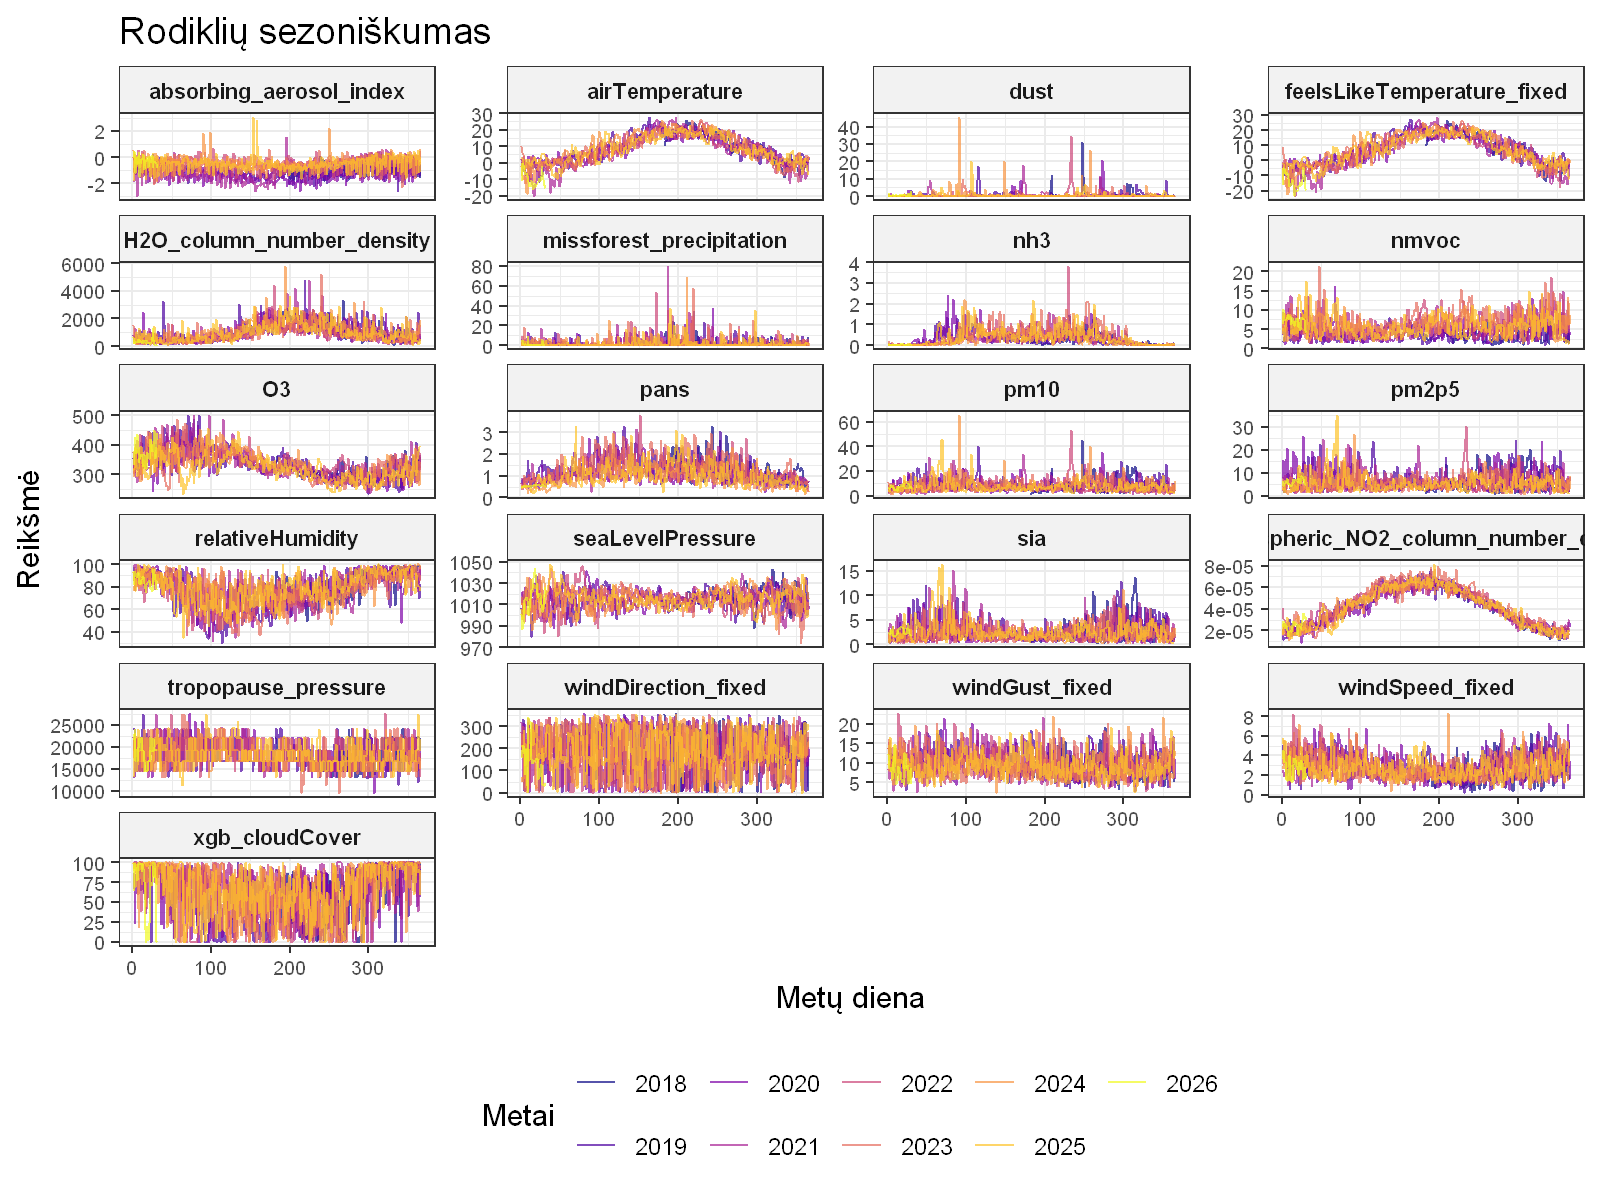

In [5]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)
data_clean %>%
  dplyr::select(observationTime, where(is.numeric)) %>%
  dplyr::mutate(
    Metai = as.factor(year(observationTime)),
    Metų_diena = yday(observationTime)) %>%
  tidyr::pivot_longer(cols = -c(observationTime, Metai, Metų_diena), 
                      names_to = "variable", 
                      values_to = "value") %>%
  ggplot(aes(x = Metų_diena, y = value, color = Metai, group = Metai)) +
  geom_line(alpha = 0.7, linewidth = 0.5) +
  facet_wrap(~variable, scales = "free_y", ncol = 4) + 
  theme_bw() +
  scale_color_viridis_d(option = "plasma") + # Gražios, kontrastingos spalvos metams
  theme(
    legend.position = "bottom",
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(size = 8, face = "bold"),
    axis.text = element_text(size = 7)) +
  labs(
    x = "Metų diena",
    y = "Reikšmė",
    color = "Metai",
    title = "Rodiklių sezoniškumas")

# ggsave(filename = "sezoniskumas.png", width = 12, height = 15, units = "in", dpi = 300)

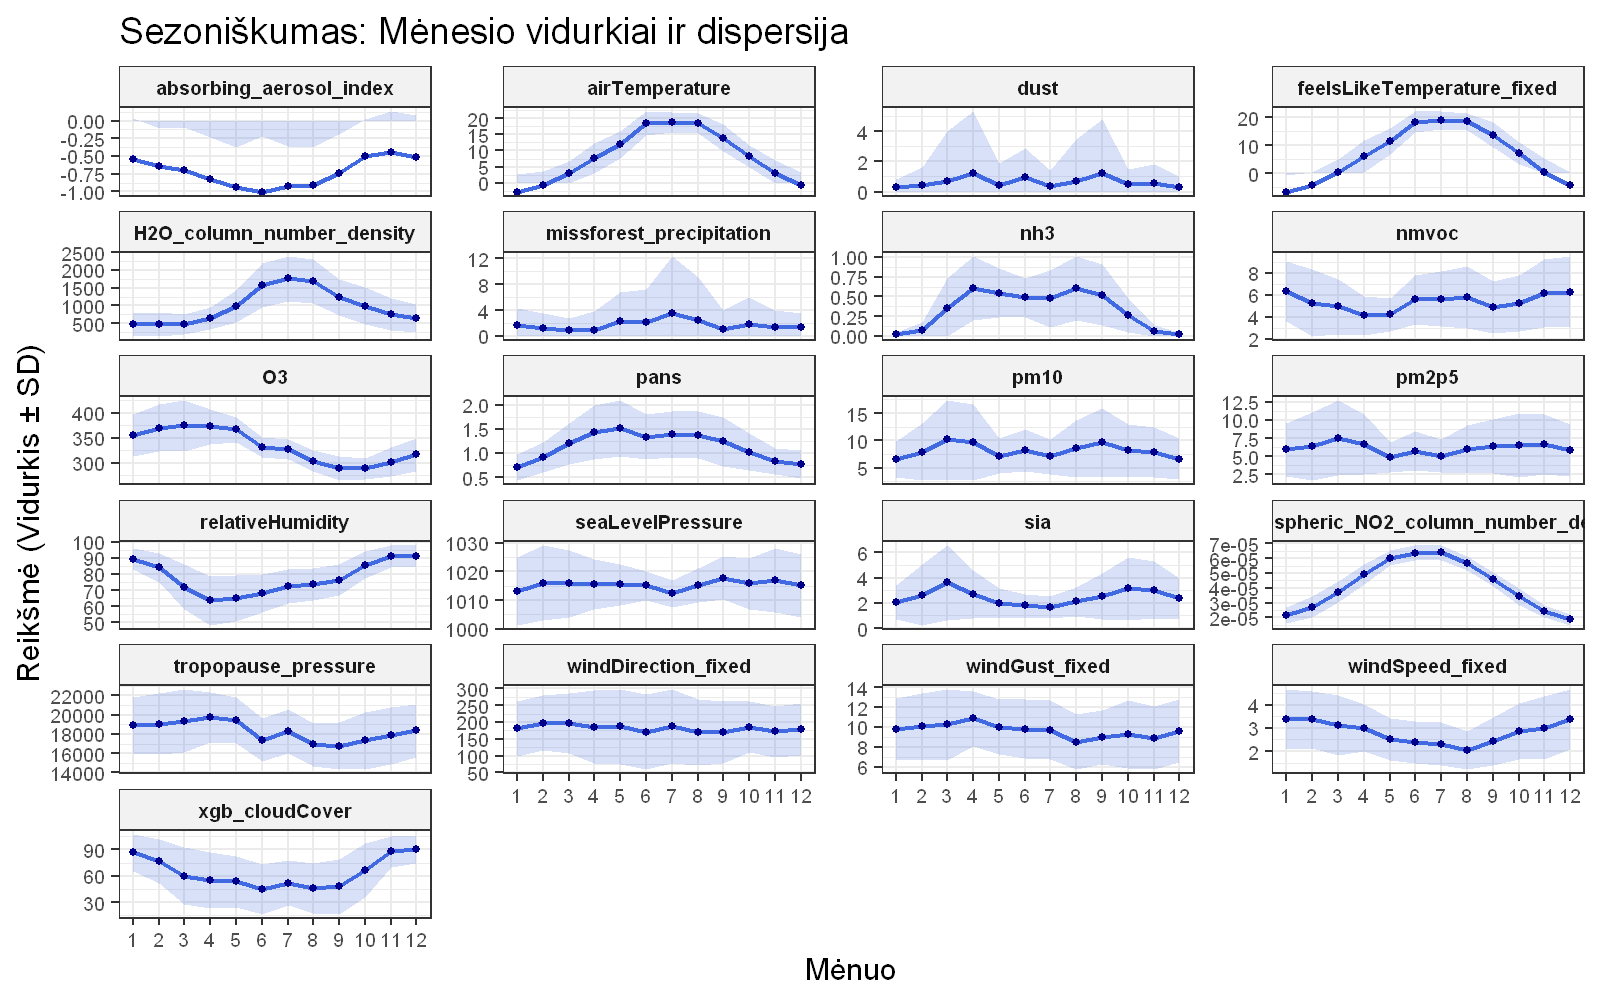

In [6]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
data_clean %>%
  dplyr::select(observationTime, where(is.numeric)) %>%
  dplyr::mutate(Menuo = month(observationTime)) %>%
  tidyr::pivot_longer(cols = -c("observationTime", "Menuo"), 
                      names_to = "variable", 
                      values_to = "value") %>%
  dplyr::group_by(variable, Menuo) %>%
  dplyr::summarise(
    vidurkis = mean(value, na.rm = TRUE),
    nuokrypis = sd(value, na.rm = TRUE),
    .groups = "drop") %>%

  ggplot(aes(x = Menuo, y = vidurkis)) +
  geom_ribbon(aes(ymin = pmax(0, vidurkis - nuokrypis), ymax = vidurkis + nuokrypis), 
              fill = "royalblue", alpha = 0.2) +
  geom_line(color = "royalblue", linewidth = 0.8) +
  geom_point(color = "darkblue", size = 1.1) +
  facet_wrap(~variable, scales = "free_y", ncol = 4) + 
  scale_x_continuous(breaks = 1:12) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(size = 7, face = "bold"),
    axis.text = element_text(size = 7),
    panel.grid.minor.x = element_blank()) +
  labs(
    x = "Mėnuo",
    y = "Reikšmė (Vidurkis ± SD)",
    title = "Sezoniškumas: Mėnesio vidurkiai ir dispersija")

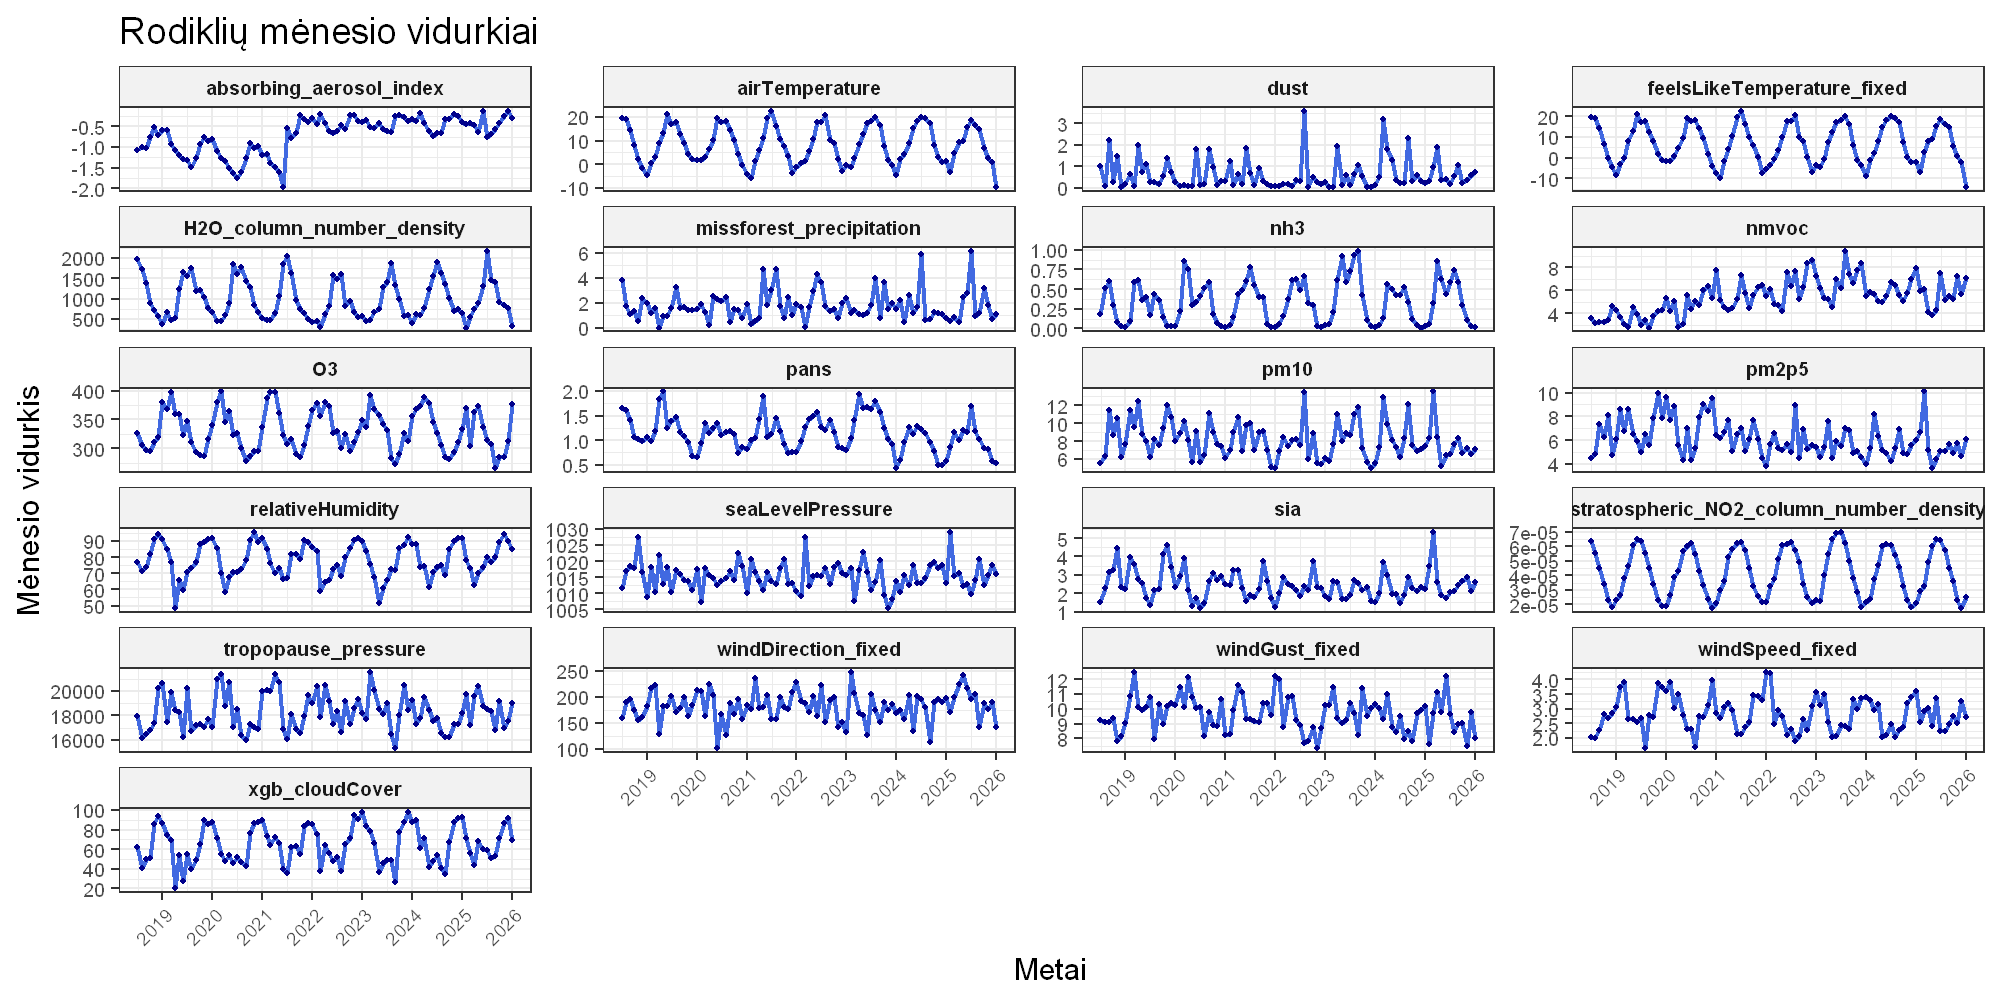

In [7]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)
data_clean %>%
  dplyr::select(observationTime, where(is.numeric)) %>%
  dplyr::mutate(Month = lubridate::floor_date(observationTime, "month")) %>%
  tidyr::pivot_longer(cols = -c("observationTime", "Month"), 
                      names_to = "variable", 
                      values_to = "value") %>%
  dplyr::group_by(variable, Month) %>%
  dplyr::summarise(mean = mean(value, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = Month, y = mean)) +
  geom_line(color = "royalblue", linewidth = 0.7) +
  geom_point(color = "darkblue", size = 0.75) +
  facet_wrap(~variable, scales = "free_y", ncol = 4) + 
  scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(size = 7, face = "bold"),
    axis.text = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    x = "Metai",
    y = "Mėnesio vidurkis",
    title = "Rodiklių mėnesio vidurkiai")

## Decompozicija

In [8]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "absorbing_aerosol_index"                
 [3] "stratospheric_NO2_column_number_density"
 [4] "tropopause_pressure"                    
 [5] "H2O_column_number_density"              
 [6] "O3"                                     
 [7] "pm10"                                   
 [8] "pm2p5"                                  
 [9] "sia"                                    
[10] "nmvoc"                                  
[11] "dust"                                   
[12] "nh3"                                    
[13] "pans"                                   
[14] "airTemperature"                         
[15] "seaLevelPressure"                       
[16] "relativeHumidity"                       
[17] "missforest_precipitation"               
[18] "xgb_cloudCover"                         
[19] "feelsLikeTemperature_fixed"             
[20] "windSpeed_fixed"                        
[21] "windGust_fixed"                         
[22] "windDirection_fixed"

In [9]:
need_for_decomposition <- c('absorbing_aerosol_index', 'airTemperature', 'feelsLikeTemperature_fixed', 'H2O_column_number_density',
                            'nh3', 'nmvoc', 'O3', 'pans', 'relativeHumidity', 'seaLevelPressure', 'sia',
                            'stratospheric_NO2_column_number_density', 'tropopause_pressure','windGust_fixed',
                            'windSpeed_fixed', 'xgb_cloudCover')

In [10]:
no_need_for_decomposition <- c('pm10', 'pm2p5', 'dust', 'missforest_precipitation', 'windDirection_fixed')

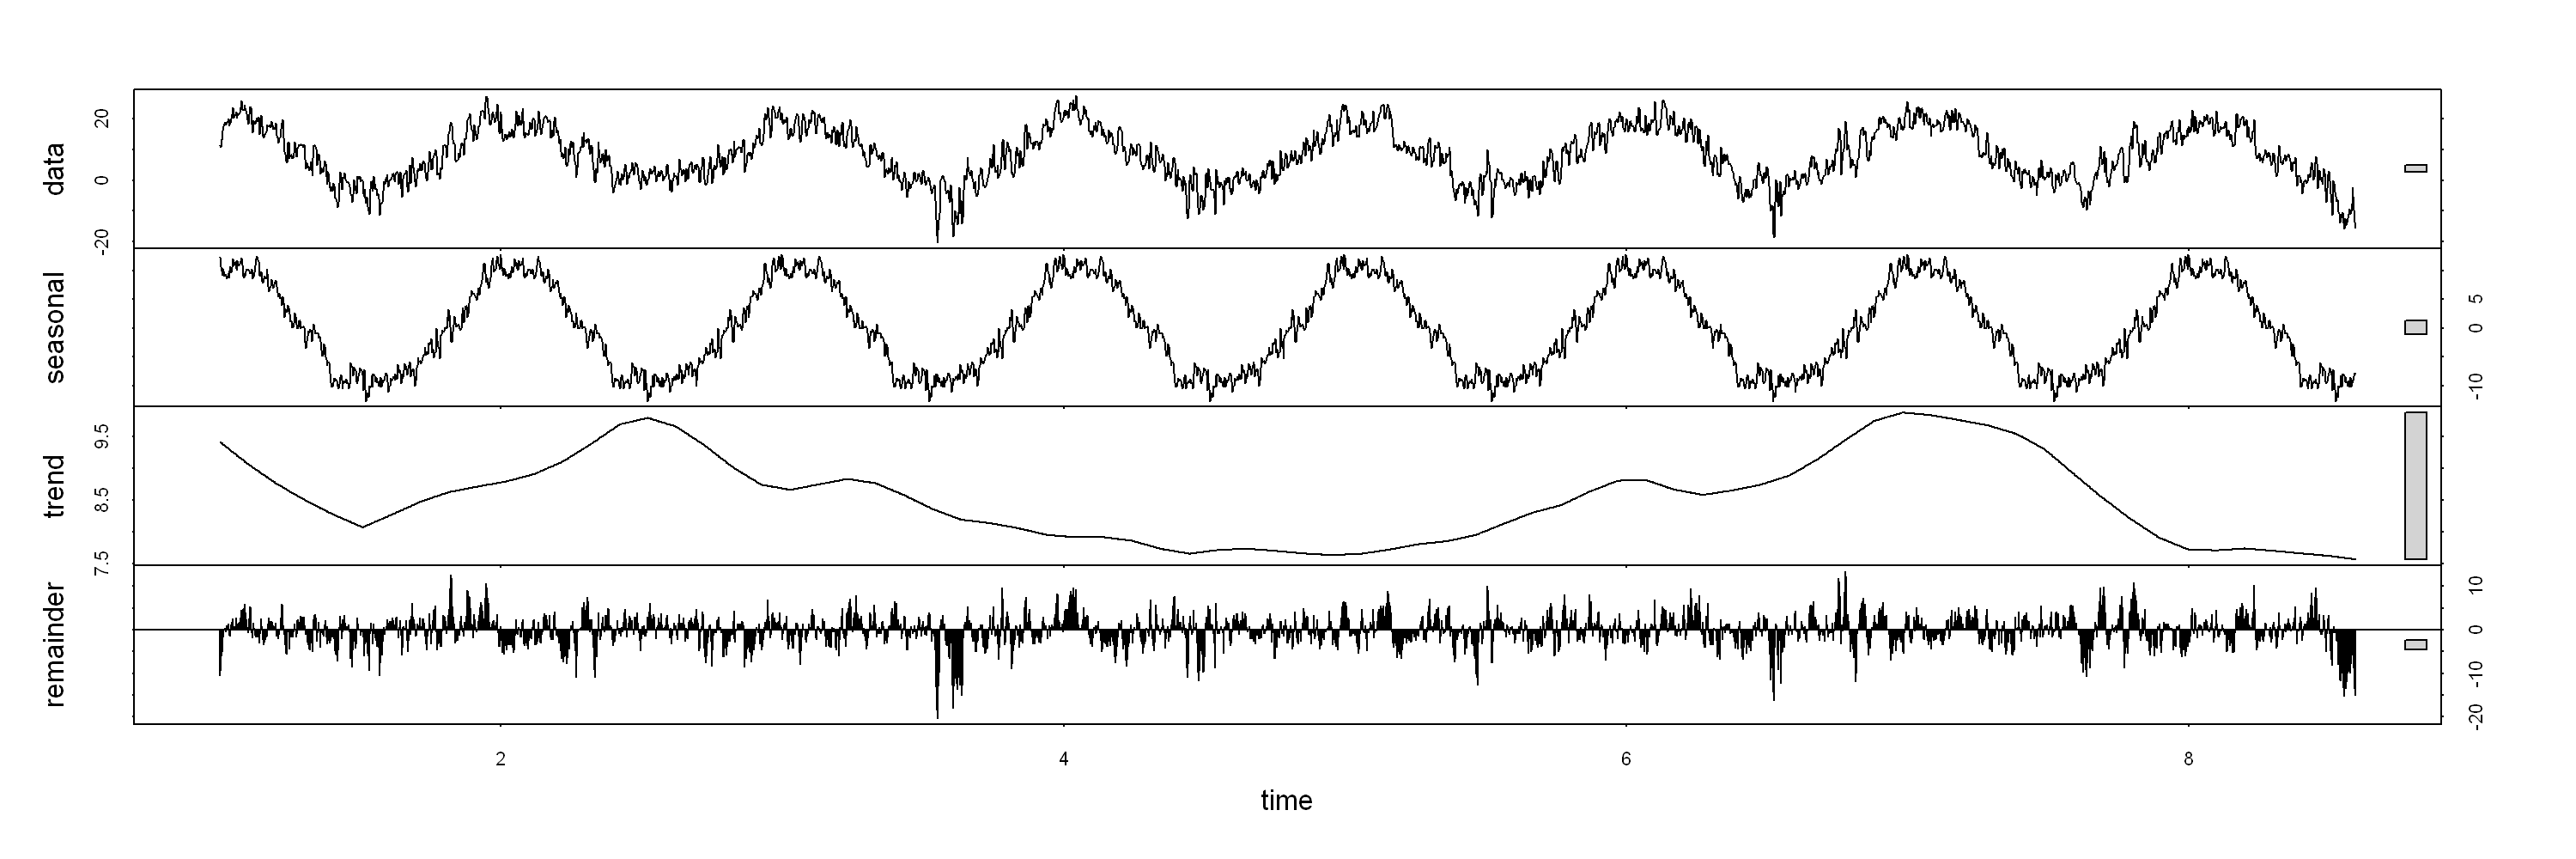

In [11]:
options(repr.plot.width = 15, repr.plot.height = 5, repr.plot.res = 200)
temperature_ts <- ts(data_clean$airTemperature, frequency = 365)
# ggtsdisplay(temperature_ts, theme = theme_bw())
mdl_smooth_loess_01 <- stats::stl(temperature_ts, s.window = 365, t.window = 365, robust = TRUE)
plot(mdl_smooth_loess_01)

In [12]:
stl_decomposition <- function(data, column_name){
    column_ts <- ts(data[[column_name]], frequency = 365)
    mdl_stl <- stats::stl(column_ts, s.window = 365, t.window = 365, robust = TRUE)
    stl_components <- as.data.frame(mdl_stl$time.series)

    new_col_name <- paste0(column_name, "_res")
    data[[new_col_name]] <- stl_components$remainder
    data[[column_name]] <- NULL

    return(data)
}

In [13]:
new_data_clean <- data_clean

for (col in need_for_decomposition) {
    new_data_clean <- stl_decomposition(new_data_clean, col)
}

colnames(new_data_clean)

[1] "observationTime"                            
 [2] "pm10"                                       
 [3] "pm2p5"                                      
 [4] "dust"                                       
 [5] "missforest_precipitation"                   
 [6] "windDirection_fixed"                        
 [7] "absorbing_aerosol_index_res"                
 [8] "airTemperature_res"                         
 [9] "feelsLikeTemperature_fixed_res"             
[10] "H2O_column_number_density_res"              
[11] "nh3_res"                                    
[12] "nmvoc_res"                                  
[13] "O3_res"                                     
[14] "pans_res"                                   
[15] "relativeHumidity_res"                       
[16] "seaLevelPressure_res"                       
[17] "sia_res"                                    
[18] "stratospheric_NO2_column_number_density_res"
[19] "tropopause_pressure_res"                    
[20] "windGust_fixed_res"                         
[21] "windSpeed_fixed_res"                        
[22] "xgb_cloudCover_res"

### Išskirčių skaičius pagal tarpkvartilinį plotą

In [14]:
count_outliers_IQR <- function(data, var_name) {
  data %>%
    summarise(
      variable = var_name,
      Q1 = quantile(.data[[var_name]], 0.25),
      Q3 = quantile(.data[[var_name]], 0.75),
      H = Q3 - Q1,
      outer_low = Q1 - 3*H,
      outer_high = Q3 + 3*H,
      IQR_extreme_outliers = sum(.data[[var_name]] < outer_low | .data[[var_name]] > outer_high)
      )
}

In [15]:
numeric_cols <- new_data_clean %>% 
  dplyr::select(where(is.numeric)) %>% 
  names()

results_list_full <- lapply(numeric_cols, function(col) count_outliers_IQR(new_data_clean, col))
IQR_outlier_summary_full <- bind_rows(results_list_full)

IQR_outlier_summary_full %>%
  mutate(across(where(is.numeric), ~ format(.x, scientific = FALSE, digits = 4, big.mark = "")))

IQR_outlier_summary_full

variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
pm10,4.84611535,10.161503875,5.315388525,-11.10005023,26.10766945,24
pm2p5,3.42960510,7.746220550,4.316615450,-9.52024125,20.69606690,17
dust,0.02308564,0.381378448,0.358292806,-1.05179277,1.45625687,248
missforest_precipitation,0.00000000,1.600000000,1.600000000,-4.80000000,6.40000000,219
windDirection_fixed,126.00000000,263.000000000,137.000000000,-285.00000000,674.00000000,0
absorbing_aerosol_index_res,-0.22432328,0.206578903,0.430902178,-1.51702981,1.49928544,30
airTemperature_res,-2.15124984,1.943651570,4.094901410,-14.43595407,14.22835580,8
feelsLikeTemperature_fixed_res,-2.40110817,2.152022685,4.553130853,-16.06050073,15.81141525,8
H2O_column_number_density_res,-182.09039593,240.014984242,422.105380167,-1448.40653643,1506.33112474,31


variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
pm10,4.846115e+00,1.016150e+01,5.315389e+00,-1.110005e+01,2.610767e+01,24
pm2p5,3.429605e+00,7.746221e+00,4.316615e+00,-9.520241e+00,2.069607e+01,17
dust,2.308564e-02,3.813784e-01,3.582928e-01,-1.051793e+00,1.456257e+00,248
missforest_precipitation,0.000000e+00,1.600000e+00,1.600000e+00,-4.800000e+00,6.400000e+00,219
windDirection_fixed,1.260000e+02,2.630000e+02,1.370000e+02,-2.850000e+02,6.740000e+02,0
absorbing_aerosol_index_res,-2.243233e-01,2.065789e-01,4.309022e-01,-1.517030e+00,1.499285e+00,30
airTemperature_res,-2.151250e+00,1.943652e+00,4.094901e+00,-1.443595e+01,1.422836e+01,8
feelsLikeTemperature_fixed_res,-2.401108e+00,2.152023e+00,4.553131e+00,-1.606050e+01,1.581142e+01,8
H2O_column_number_density_res,-1.820904e+02,2.400150e+02,4.221054e+02,-1.448407e+03,1.506331e+03,31


### Išskirčių skaičius pagal tarpkvartilinį plotą išfiltravus KRITULIŲ nulius

In [16]:
data_without_zeros <- new_data_clean %>%
  filter(missforest_precipitation>0)

results_list_0 <- lapply(numeric_cols, function(col) count_outliers_IQR(data_without_zeros, col))
IQR_outlier_summary_0 <- bind_rows(results_list_0)
IQR_outlier_summary_0

variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
pm10,4.188746e+00,8.467252e+00,4.278506e+00,-8.646772e+00,2.130277e+01,4
pm2p5,3.037258e+00,6.678534e+00,3.641276e+00,-7.886568e+00,1.760236e+01,4
dust,1.309418e-02,1.822218e-01,1.691276e-01,-4.942887e-01,6.896047e-01,120
missforest_precipitation,6.000000e-01,4.500000e+00,3.900000e+00,-1.110000e+01,1.620000e+01,42
windDirection_fixed,1.390000e+02,2.590000e+02,1.200000e+02,-2.210000e+02,6.190000e+02,0
absorbing_aerosol_index_res,-2.294708e-01,1.832139e-01,4.126846e-01,-1.467525e+00,1.421268e+00,22
airTemperature_res,-2.339377e+00,1.693023e+00,4.032401e+00,-1.443658e+01,1.379022e+01,2
feelsLikeTemperature_fixed_res,-2.750525e+00,1.900260e+00,4.650786e+00,-1.670288e+01,1.585262e+01,3
H2O_column_number_density_res,-1.850987e+02,1.911784e+02,3.762771e+02,-1.313930e+03,1.320010e+03,26


## Vizualizacija

In [17]:
identify_outliers <- function(data, var_name) {
    stats <- data %>%
        summarise(
            Q1 = quantile(.data[[var_name]], 0.25),
            Q3 = quantile(.data[[var_name]], 0.75),
            H = Q3 - Q1) %>%
        mutate(
            outer_low = Q1 - 3 * H,
            outer_high = Q3 + 3 * H)

    data %>%
        mutate(
            is_outlier = ifelse((.data[[var_name]] < stats$outer_low | .data[[var_name]] > stats$outer_high), 1, 0))
}

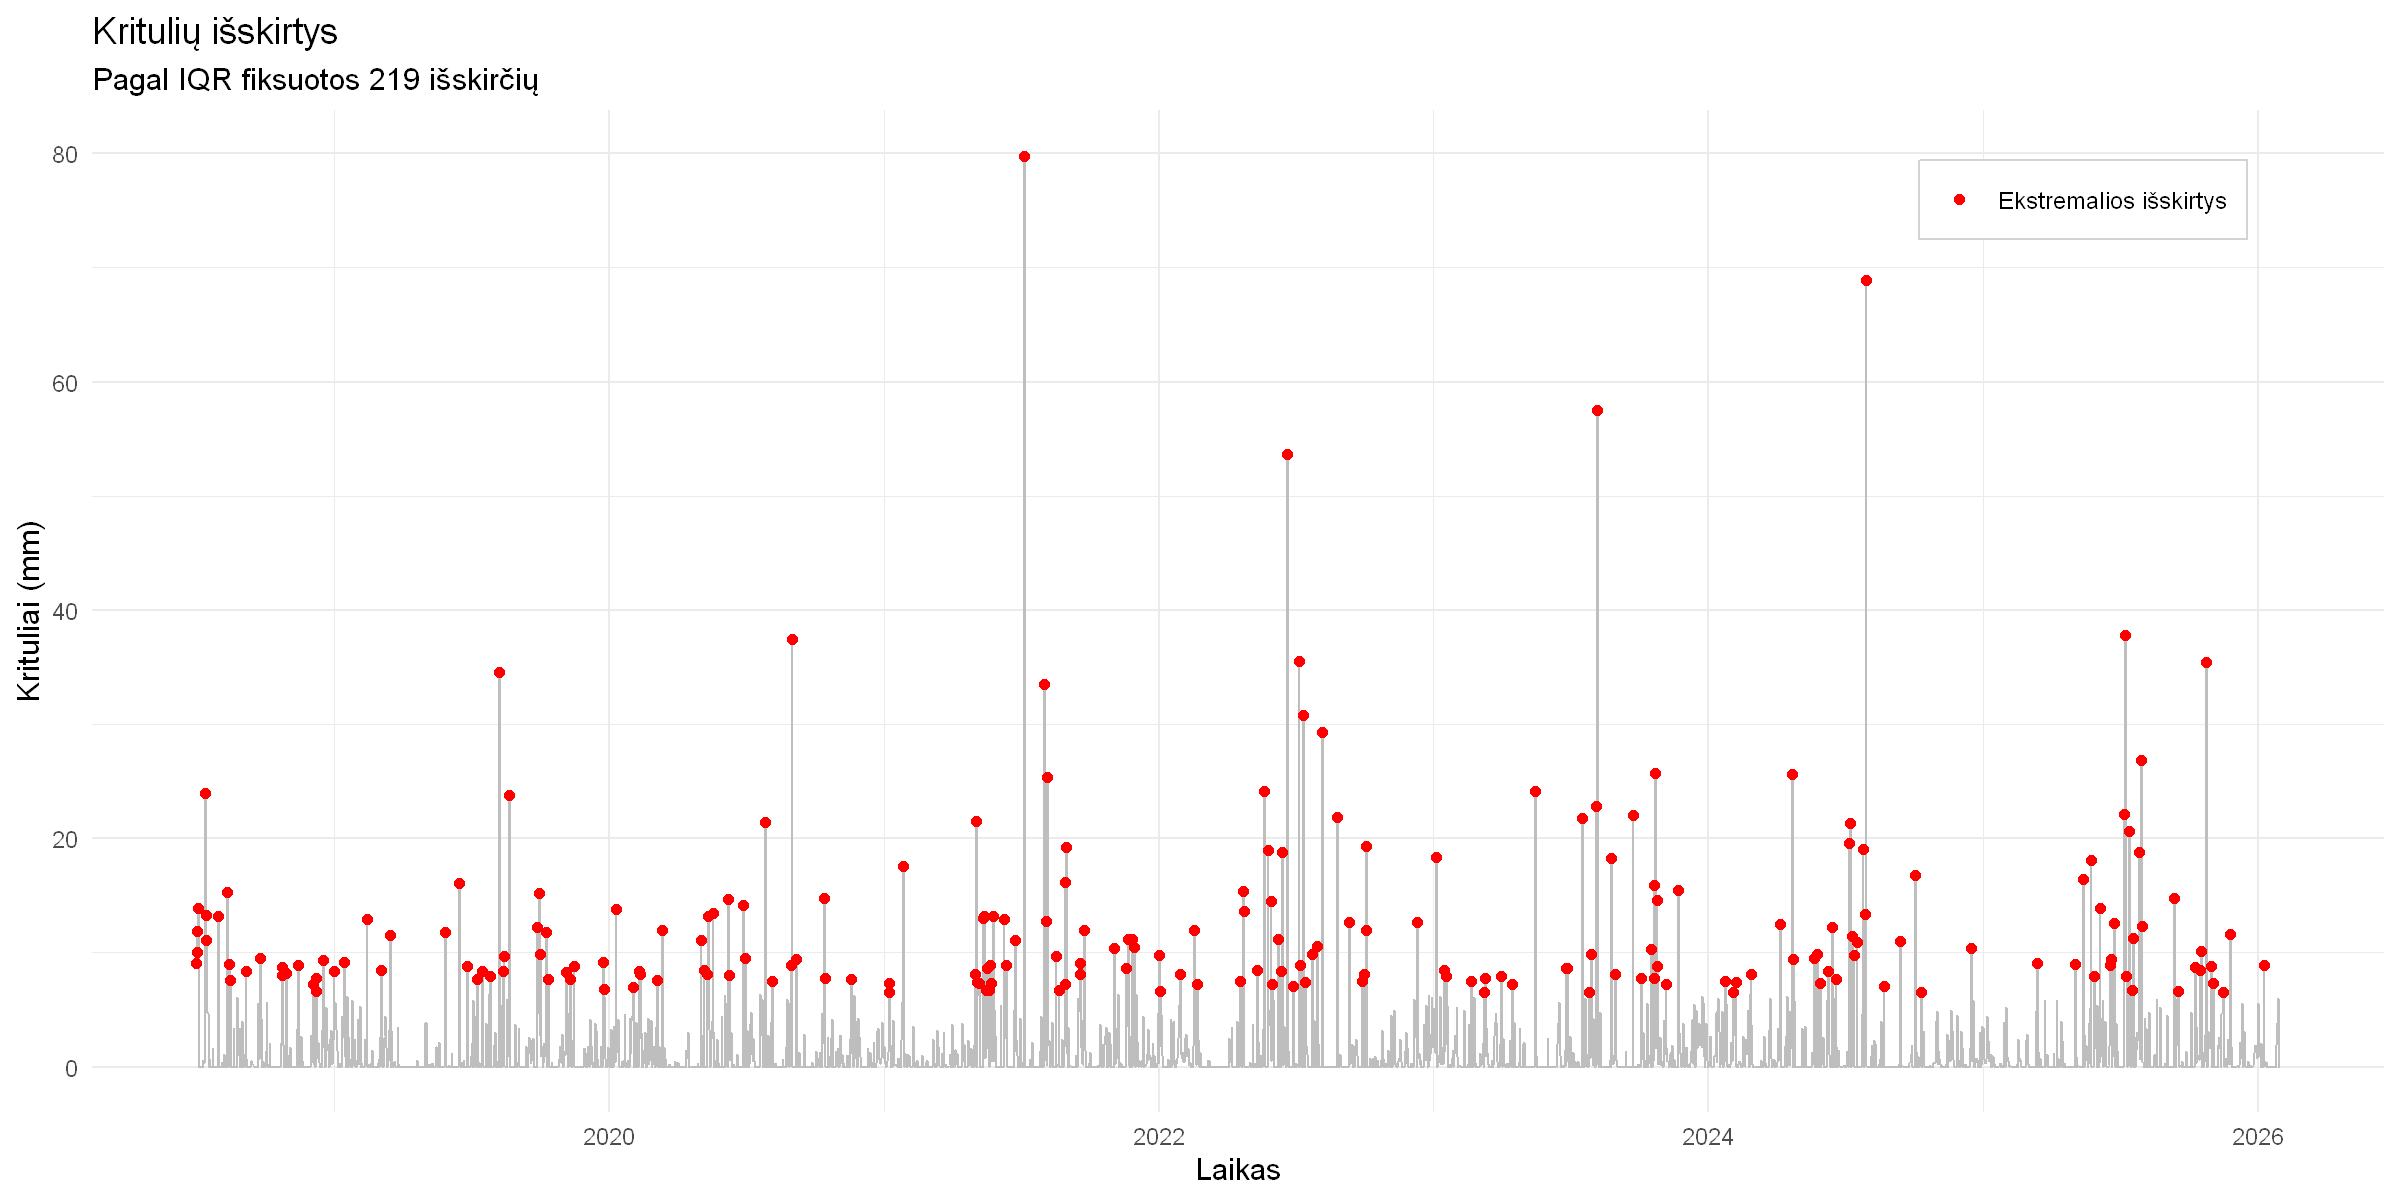

In [18]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

data_with_outliers <- identify_outliers(new_data_clean, 'missforest_precipitation')

ggplot(data_with_outliers, aes(x = observationTime, y = missforest_precipitation, color = as.factor(is_outlier))) +
  geom_line(color = 'grey') +
  geom_point(data = subset(data_with_outliers, is_outlier == 1), 
             aes(color = as.factor(is_outlier))) +
  scale_color_manual(values = c("1" = "red"),
                     labels = c("Ekstremalios išskirtys")) +
  theme_minimal() +
  theme(legend.position = c(0.94, 0.95), legend.justification = c("right", "top"), 
        legend.background = element_rect(fill = "white", color = "lightgrey"), legend.title = element_blank()) +
  labs(title = "Kritulių išskirtys", , subtitle = "Pagal IQR fiksuotos 219 išskirčių", x = "Laikas", y = "Krituliai (mm)")

In [19]:
data_with_outliers <- identify_outliers(data_without_zeros, 'missforest_precipitation')

data_plot_extreme_outliers <- new_data_clean %>%
  left_join(data_with_outliers %>% select(observationTime, is_outlier), by = "observationTime")

data_plot_extreme_outliers$is_outlier[is.na(data_plot_extreme_outliers$is_outlier)] <- 0

In [20]:
length(data_plot_extreme_outliers$is_outlier[data_plot_extreme_outliers$is_outlier == 1])

[1] 42

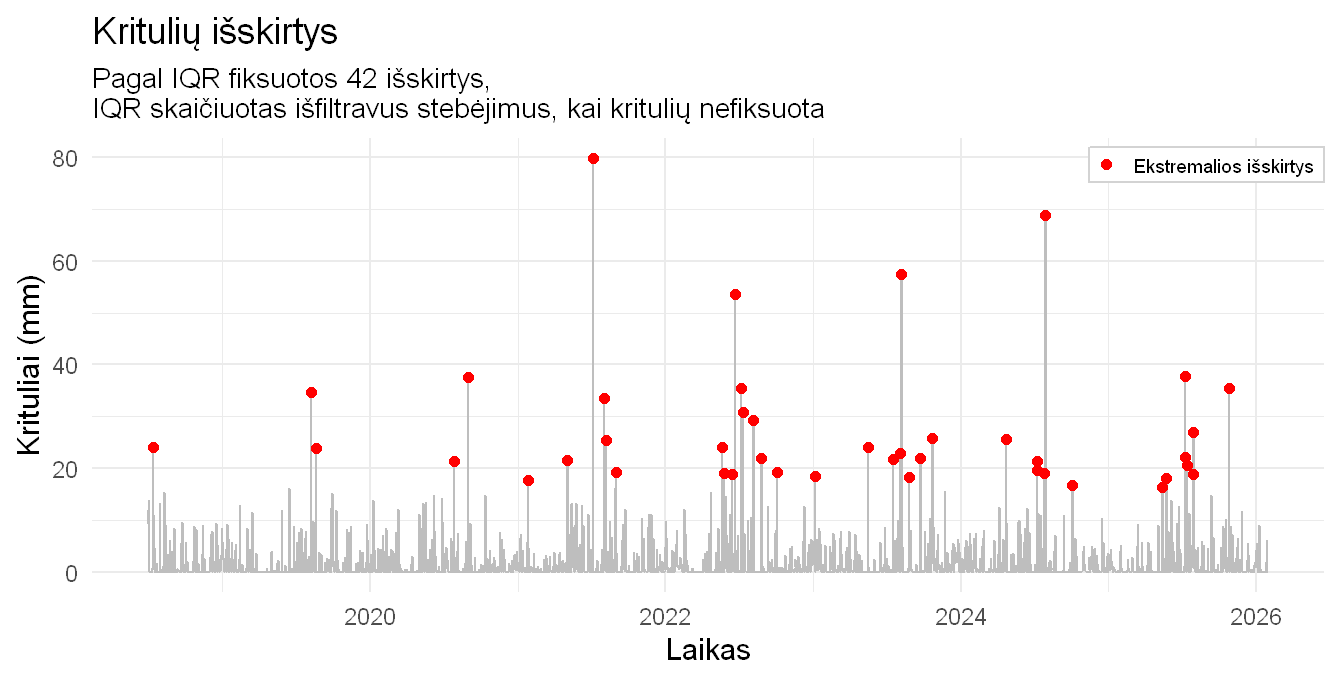

In [21]:
options(repr.plot.width = 6.7, repr.plot.height = 3.4, unit='in', repr.plot.res = 200)

ggplot(data_plot_extreme_outliers, aes(x = observationTime, y = missforest_precipitation, color = as.factor(is_outlier))) +
  geom_line(color = 'grey') +
  geom_point(data = subset(data_plot_extreme_outliers, is_outlier == 1), aes(color = as.factor(is_outlier))) +
  scale_color_manual(values = c("1" = "red"), labels = c("Ekstremalios išskirtys")) +
  theme_minimal() +
  theme(legend.position = c(1, 0.98), legend.justification = c("right", "top"), 
        legend.background = element_rect(fill = "white", color = "lightgrey"), legend.title = element_blank(),
        legend.text = element_text(size = 7), legend.key.size = unit(0.3, "cm"), legend.margin = margin(2, 2, 2, 2),
        plot.subtitle = element_text(size = 10)) +
  labs(title = "Kritulių išskirtys", subtitle = "Pagal IQR fiksuotos 42 išskirtys, \nIQR skaičiuotas išfiltravus stebėjimus, kai kritulių nefiksuota",  x = "Laikas", y = "Krituliai (mm)")

ggsave(filename = "outliers_plot.png", width = 6, height = 3.7, units = "in", dpi = 300)

In [22]:
data_plot_extreme_outliers_80 <- data_plot_extreme_outliers %>%
    filter(missforest_precipitation > 75)

data_plot_extreme_outliers_80

observationTime,pm10,pm2p5,dust,missforest_precipitation,windDirection_fixed,absorbing_aerosol_index_res,airTemperature_res,feelsLikeTemperature_fixed_res,H2O_column_number_density_res,⋯,pans_res,relativeHumidity_res,seaLevelPressure_res,sia_res,stratospheric_NO2_column_number_density_res,tropopause_pressure_res,windGust_fixed_res,windSpeed_fixed_res,xgb_cloudCover_res,is_outlier
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2021-07-06,9.406171,7.182391,0.8799755,79.8,36,0.5179526,3.437643,3.511115,861.9862,⋯,0.1606809,11.83478,2.520683,0.5262412,-1.03324e-05,-4330.038,-0.01033033,-0.9106734,-2.930759,1


## Daugiamatės išskirtys

### Skaičiuojama pagal kiek požymių stebėjimas laikomas išskirtimi

In [23]:
check_bounds <- function(x, col_name, info) {
  limits <- info[info$variable == col_name, ]
  as.integer(x < as.numeric(limits$outer_low) | x > as.numeric(limits$outer_high))
}

In [24]:
IQR_outlier_summary_combined <- IQR_outlier_summary_full %>%
  filter(variable != "missforest_precipitation") %>%
  bind_rows(IQR_outlier_summary_0 %>% filter(variable == "missforest_precipitation"))

In [25]:
data_outlier_info <- new_data_clean %>%
  mutate(across(all_of(numeric_cols), ~ check_bounds(.x, cur_column(), IQR_outlier_summary_combined), .names = "is_out_by_{.col}"))

data_outlier_info <- data_outlier_info %>%
  mutate(outlier_dim = rowSums(across(starts_with("is_out_by_")), na.rm = TRUE)) %>%
  arrange(desc(outlier_dim))

data_outlier_info <- data_outlier_info %>%
  mutate(is_outlier = as.integer(outlier_dim > 1) )

In [26]:
outliers_4 <- data_outlier_info %>% 
  filter(outlier_dim == 4)

nrow(outliers_4)
outliers_4

[1] 7

observationTime,pm10,pm2p5,dust,missforest_precipitation,windDirection_fixed,absorbing_aerosol_index_res,airTemperature_res,feelsLikeTemperature_fixed_res,H2O_column_number_density_res,⋯,is_out_by_relativeHumidity_res,is_out_by_seaLevelPressure_res,is_out_by_sia_res,is_out_by_stratospheric_NO2_column_number_density_res,is_out_by_tropopause_pressure_res,is_out_by_windGust_fixed_res,is_out_by_windSpeed_fixed_res,is_out_by_xgb_cloudCover_res,outlier_dim,is_outlier
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
2019-02-18,26.762316,22.458235,1.9492027,0.0,167,-0.310439841,-1.7531496,0.3751883,97.03388,⋯,0,0,1,0,0,0,0,0,4,1
2019-10-24,27.645723,24.040201,3.9779890,0.0,133,0.228376516,-0.3125691,0.9664928,-38.66845,⋯,0,0,1,0,0,0,0,0,4,1
2020-03-27,20.382483,21.214102,0.7722217,0.0,2,0.003448516,1.0020858,2.6003329,-99.04800,⋯,1,0,0,0,0,0,0,0,4,1
2021-02-22,30.945520,24.592295,5.2231154,0.0,24,1.467042577,1.8340652,3.6747126,87.42630,⋯,0,0,1,0,0,0,0,0,4,1
2024-04-01,65.333084,26.978867,44.7548370,0.0,166,0.276029370,11.1579160,14.1371198,796.58062,⋯,0,0,0,0,0,0,0,0,4,1
2024-04-22,4.414152,3.419024,0.1083328,25.6,256,-0.108116662,-11.9167072,-16.7419326,-255.07866,⋯,1,0,0,0,0,0,0,0,4,1
2025-03-08,25.617004,19.635332,2.0612907,0.0,174,0.487984848,5.1259872,6.8254273,152.38764,⋯,0,0,1,0,0,0,0,0,4,1


In [27]:
outliers_3 <- data_outlier_info %>% 
  filter(outlier_dim == 3)

nrow(outliers_3)
outliers_3

[1] 19

observationTime,pm10,pm2p5,dust,missforest_precipitation,windDirection_fixed,absorbing_aerosol_index_res,airTemperature_res,feelsLikeTemperature_fixed_res,H2O_column_number_density_res,⋯,is_out_by_relativeHumidity_res,is_out_by_seaLevelPressure_res,is_out_by_sia_res,is_out_by_stratospheric_NO2_column_number_density_res,is_out_by_tropopause_pressure_res,is_out_by_windGust_fixed_res,is_out_by_windSpeed_fixed_res,is_out_by_xgb_cloudCover_res,outlier_dim,is_outlier
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
2018-09-05,45.230804,18.179276,31.24583600,8.4,19,0.24905817,1.0490829,1.0356582,-119.50363,⋯,0,0,0,0,0,0,0,0,3,1
2018-09-18,21.234407,18.114202,0.14934918,0.0,220,-0.12596301,2.8286679,2.9855297,886.38049,⋯,0,0,1,0,0,0,0,0,3,1
2018-09-20,21.973093,17.481745,0.52490455,0.0,153,-0.09325472,5.1330826,4.9445298,311.44719,⋯,0,0,1,0,0,0,0,0,3,1
2019-04-25,34.679880,20.895327,16.74461200,0.0,133,0.27224127,4.7770698,4.1438186,160.51085,⋯,0,0,0,0,0,0,0,0,3,1
2019-04-26,40.409090,23.887260,17.17304000,0.0,128,-0.01936814,9.3985906,7.7068334,605.16975,⋯,0,0,0,0,0,0,0,0,3,1
2021-03-25,28.657745,22.583055,0.07895818,0.0,271,-0.14710474,0.6385384,0.7928733,58.49618,⋯,0,0,1,0,0,0,0,0,3,1
2021-04-29,16.665094,13.982285,1.14225660,0.0,130,-0.45011931,0.8818575,0.4935295,-23.29254,⋯,0,0,1,0,0,0,0,0,3,1
2021-06-22,33.423420,22.113290,17.78331400,0.0,138,-0.19271065,8.0391532,8.4411577,1400.48195,⋯,0,0,0,0,0,0,0,0,3,1
2021-07-15,12.345680,10.258317,2.46272600,0.0,247,2.37208873,7.4599625,8.1696826,67.50561,⋯,0,0,0,0,0,0,0,0,3,1


In [28]:
outliers_2 <- data_outlier_info %>% 
  filter(outlier_dim == 2)

nrow(outliers_2)
head(outliers_2)

[1] 86

,observationTime,pm10,pm2p5,dust,missforest_precipitation,windDirection_fixed,absorbing_aerosol_index_res,airTemperature_res,feelsLikeTemperature_fixed_res,H2O_column_number_density_res,⋯,is_out_by_relativeHumidity_res,is_out_by_seaLevelPressure_res,is_out_by_sia_res,is_out_by_stratospheric_NO2_column_number_density_res,is_out_by_tropopause_pressure_res,is_out_by_windGust_fixed_res,is_out_by_windSpeed_fixed_res,is_out_by_xgb_cloudCover_res,outlier_dim,is_outlier
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,2018-08-31,10.94567,8.853931,0.03053828,4,126,0.03640599,-1.385619,-1.4705510,-332.55123,⋯,0,0,0,0,0,0,0,0,2,1
2,2018-09-08,12.46723,10.312545,2.64620640,0,127,-0.29893011,0.912696,0.9321757,-27.46765,⋯,0,0,0,0,0,0,0,0,2,1
3,2018-10-31,11.61583,8.735731,1.51825630,1,144,0.32666020,2.321867,2.4509847,-134.22871,⋯,0,0,0,0,0,0,0,0,2,1
4,2018-11-01,25.13792,17.593980,7.59619700,0,145,0.52372320,3.336401,4.4009044,813.19881,⋯,0,0,1,0,0,0,0,0,2,1
5,2018-11-07,22.79466,16.879684,5.27260830,0,150,0.45488200,-0.201748,-0.8346709,-135.54242,⋯,0,0,1,0,0,0,0,0,2,1
6,2018-11-08,19.46257,15.609837,3.21161440,0,154,0.34846176,-3.224226,-2.6513883,381.68734,⋯,0,0,1,0,0,0,0,0,2,1


In [29]:
outliers_1 <- data_outlier_info %>% 
  filter(outlier_dim == 1)

nrow(outliers_1)
head(outliers_1)

[1] 567

,observationTime,pm10,pm2p5,dust,missforest_precipitation,windDirection_fixed,absorbing_aerosol_index_res,airTemperature_res,feelsLikeTemperature_fixed_res,H2O_column_number_density_res,⋯,is_out_by_relativeHumidity_res,is_out_by_seaLevelPressure_res,is_out_by_sia_res,is_out_by_stratospheric_NO2_column_number_density_res,is_out_by_tropopause_pressure_res,is_out_by_windGust_fixed_res,is_out_by_windSpeed_fixed_res,is_out_by_xgb_cloudCover_res,outlier_dim,is_outlier
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,2018-07-08,5.300079,3.732261,0.34152249,0,315,0.2340831,0.36929337,0.3099198,-305.82467,⋯,0,0,0,0,0,0,0,0,1,0
2,2018-07-10,3.166197,2.794224,0.07366047,0,5,-0.0253188,0.99095042,0.8414597,-47.30072,⋯,0,0,0,0,0,0,0,0,1,0
3,2018-07-13,2.362057,2.033328,0.01110534,24,29,-0.1175451,-0.06936972,-0.3618711,669.21041,⋯,0,0,0,0,0,0,0,0,1,0
4,2018-07-26,9.967792,8.058635,3.61028650,0,41,0.1386812,1.59179846,1.6381784,610.56590,⋯,0,0,0,0,0,0,0,0,1,0
5,2018-07-27,16.927883,12.620925,9.52787100,0,24,0.2775618,1.72037690,1.8285450,546.82231,⋯,0,0,0,0,0,0,0,0,1,0
6,2018-07-28,22.275625,14.032247,11.93030100,0,93,-0.1942065,2.85502164,3.1937455,-190.20063,⋯,0,0,0,0,0,0,0,0,1,0
